## Predicting the Profitability of an Order using Random Forest Regression

In [40]:
# Essential libraries
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import math


#### Data Sanity Check & Data Processing

In [41]:
#connect to postgreSQL

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

In [42]:
df = pd.read_sql("SELECT * FROM orders_clean", engine)

df.shape

(9994, 24)

In [43]:
df.head(3)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,category,sub-category,product_name,sales,quantity,discount,profit,year,month,profit_margin
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,2016,11,0.16
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,2016,11,0.30
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,2016,6,0.47


In [44]:
df.dtypes

row_id                    int64
order_id                    str
order_date       datetime64[us]
ship_date                   str
ship_mode                   str
customer_id                 str
customer_name               str
segment                     str
country                     str
city                        str
state                       str
postal_code               int64
region                      str
product_id                  str
category                    str
sub-category                str
product_name                str
sales                   float64
quantity                  int64
discount                float64
profit                  float64
year                      int64
month                     int64
profit_margin           float64
dtype: object

In [45]:
df['category'] = df['category'].str.lower()
df['sub-category'] = df['sub-category'].str.lower()
df['region'] = df['region'].str.lower()
df['segment'] = df['segment'].str.lower()
df['ship_mode'] = df['ship_mode'].str.lower()

df.head(3)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,category,sub-category,product_name,sales,quantity,discount,profit,year,month,profit_margin
0,1,CA-2016-152156,2016-11-08,11/11/2016,second class,CG-12520,Claire Gute,consumer,United States,Henderson,...,furniture,bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,2016,11,0.16
1,2,CA-2016-152156,2016-11-08,11/11/2016,second class,CG-12520,Claire Gute,consumer,United States,Henderson,...,furniture,chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,2016,11,0.30
2,3,CA-2016-138688,2016-06-12,6/16/2016,second class,DV-13045,Darrin Van Huff,corporate,United States,Los Angeles,...,office supplies,labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,2016,6,0.47


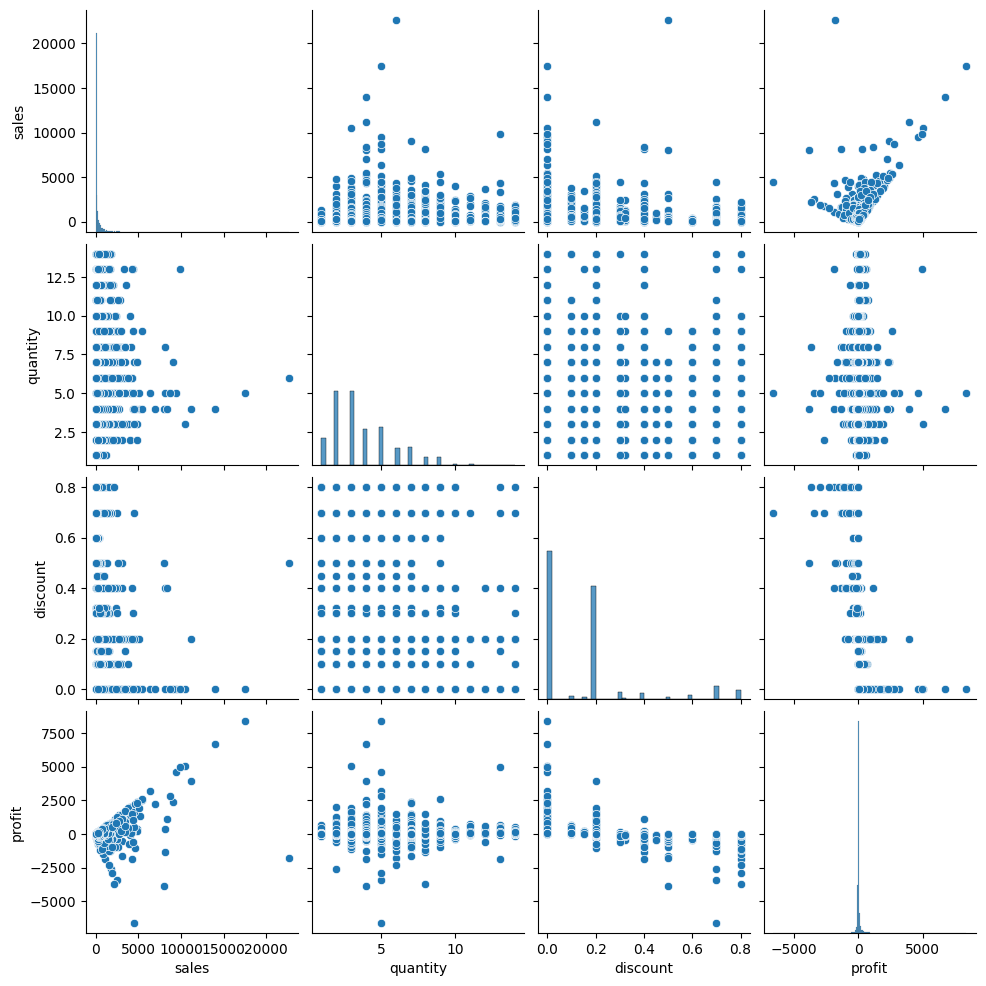

In [46]:
sns.pairplot(df[['sales', 'quantity', 'discount', 'profit']])

In [47]:
#Creating a new data frame for only the columns needed for the model
df_model = df[['sales', 'quantity', 'discount', 'category', 'sub-category', 'region', 'segment', 'ship_mode', 'profit']].copy()

#Converting categorical columns into numbers for the model to read
df_model = pd.get_dummies(df_model, columns=['category', 'sub-category', 'region', 'segment', 'ship_mode'])

#Removing profit since that is what we are trying to predict & what i am trying to predict in y
X= df_model.drop(columns=['profit'])
y= df_model['profit']

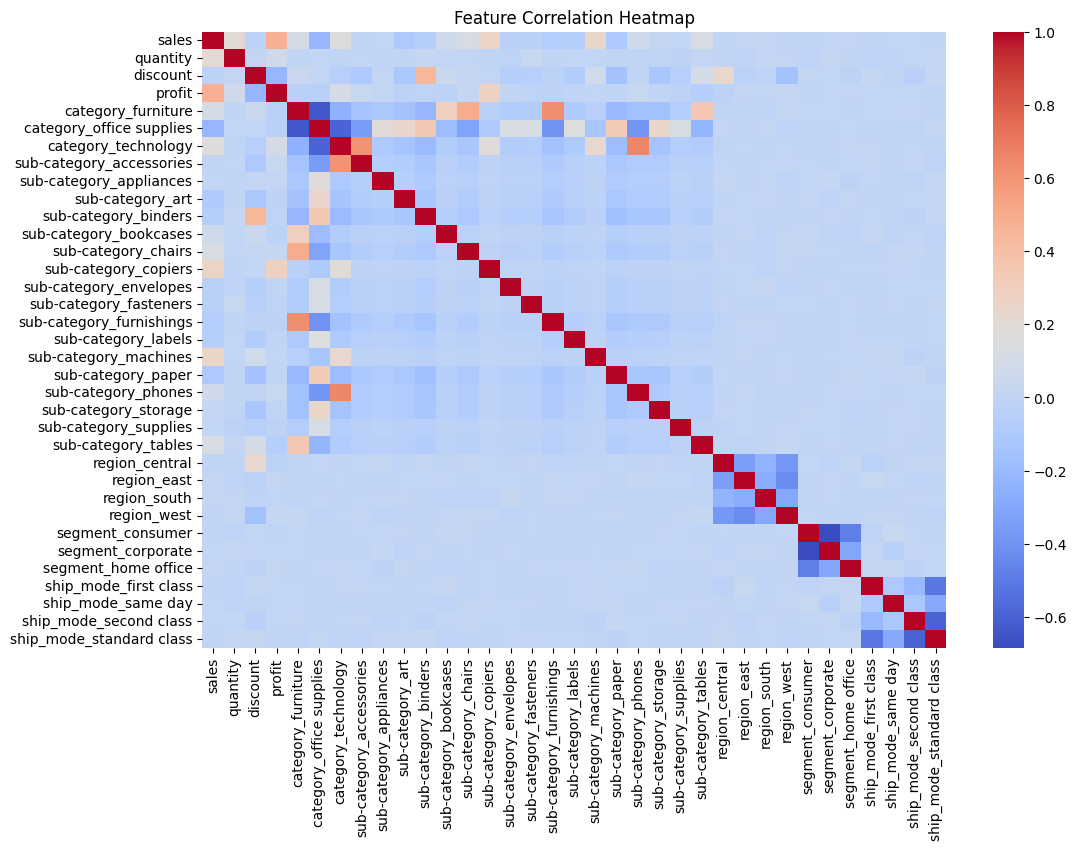

In [48]:
#Heatmap showing how all variables relate to profit 
plt.figure(figsize= (12, 8))
sns.heatmap(df_model.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

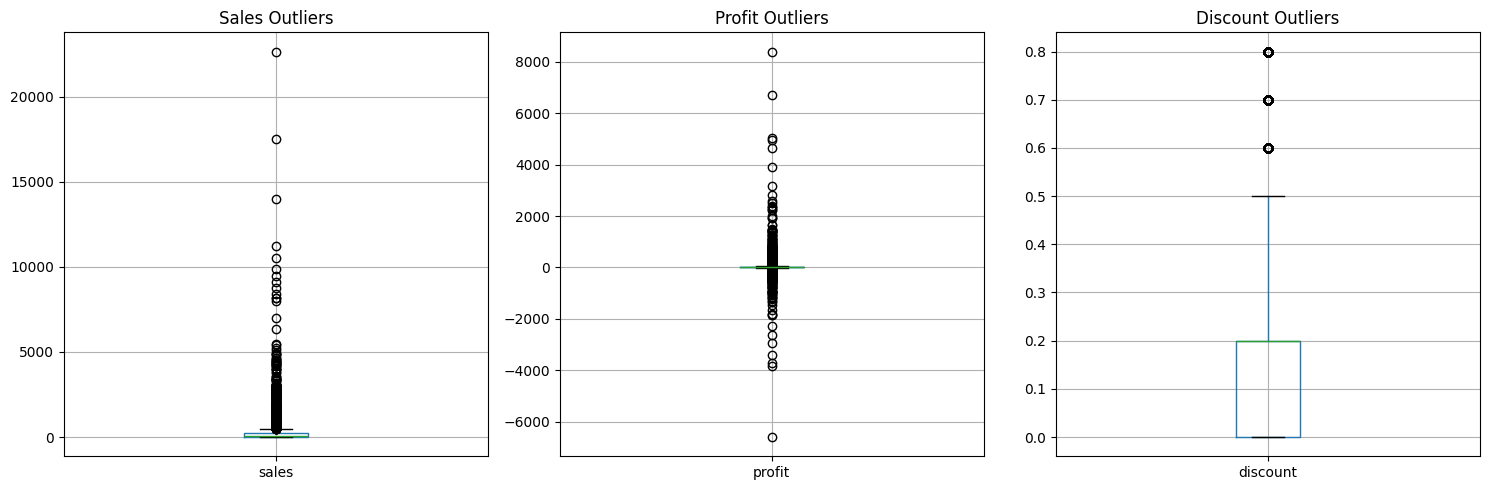

In [49]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

df.boxplot(column='sales', ax=axes[0])
axes[0].set_title('Sales Outliers')

df.boxplot(column='profit', ax=axes[1])
axes[1].set_title('Profit Outliers')

df.boxplot(column='discount', ax=axes[2])
axes[2].set_title('Discount Outliers')

plt.tight_layout()
plt.show()

Outliers displayed in sales, profit and discount column.
These outliers represent genuine orders and loss making rather than data error - retained for modelling.


#### Generate Train - Test Sets

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Modelling & Hyper-Parmameter Tuning

In [52]:
model = RandomForestRegressor(
    n_estimators=500, max_features='sqrt', oob_score=True, random_state=42)

rf = model.fit(X_train, y_train)

print(f'OOB Score: {rf.oob_score_}')

OOB Score: 0.5266026786822026


#### Variable Importance

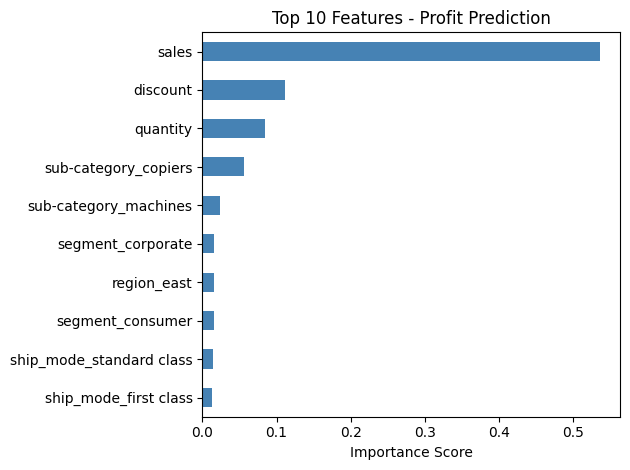

In [53]:
importances = pd.Series(rf.feature_importances_, index= rf.feature_names_in_)

plt.Figure(figsize=(10,6))
importances.sort_values().tail(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Features - Profit Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

#### Performance Evaluation

In [55]:
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mse)

print(f"MAE, {round(mae, 2)}")
print(f"RMSE, {round(rmse, 2)}")
print(f"R2, {round(r2_score(y_test, y_pred), 4)}")

MAE, 28.8
RMSE, 118.11
R2, 0.6842


MAE of £28.80 suggests a strong average accuracy
RMSE of 118.11 suggests that the model struggles with extreme profit outliers - large transactions & high discount loss making orders
Future improvements: build a seperate model for outlier trasactions or log transformation to profit 

#### Save Model

In [56]:
import pickle 

with open("random_forest_profit.pkl", "wb",) as f:
    pickle.dump(rf, f)